# Model Fitting and Selection

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_2/Notebook_2b_Model_Selection.ipynb)

In the previous notebook, we built our first models. Now we ask a harder question:

> How do we choose a model that learns the signal without memorizing the noise?

This notebook focuses on:

- loss functions,
- optimization and gradient descent,
- train/validation/test splits,
- overfitting and underfitting,
- model complexity,
- interpolation vs. extrapolation.

Big theme:

> Training error tells us how well a model fit the data it saw. Generalization tells us whether it learned something useful.

## Model Optimization = Searching for Good Parameters


### Defining the loss function

Every model we will build has **parameters**
(e.g., slope & intercept, neural network weights, polynomial coefficients).

Training means:
$$
\textbf{find parameters that make good predictions}
$$

To measure “good”, we use a **loss function**
$$
L(\beta) = \text{how wrong the model is}
$$

Examples:

- Mean Squared Error (regression):
$$
L(\beta)=\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
$$

- Classification Cross-Entropy (later in class!)

Training = **Optimization problem**
$$
\beta^* = \arg\min_{\beta} L(\beta)
$$

But how do we *actually* find \($\beta^*$\)?
Not magic ➜ **gradient descent**


### Searching for the Best Parameters (Before Gradient Descent)

Before using calculus and gradients, there is a simpler idea:

Try many possible parameter values
Compute the loss for each
Pick the one with the smallest loss

This is called **exhaustive search** or **grid search**.

Good:

- very intuitive
- guaranteed to find best value (if grid is dense enough)

Bad:

- very slow in high dimensions
- becomes impossible when models have many parameters

Let's see it in 1D first.



In [1]:
import matplotlib.pyplot as plt
import numpy as np


# Define a simple loss function
def loss(beta):
    return (beta - 2) ** 2 + 1  # minimum at beta = 2


# Search over candidate values
candidates = np.linspace(-6, 6, 200)
values = loss(candidates)

best_idx = np.argmin(values)
best_beta = candidates[best_idx]
best_loss = values[best_idx]

The animation below shows the search unfolding over time: each frame tries one
more candidate value (orange), and the best value found *so far* (red) only
updates when a new candidate beats it.


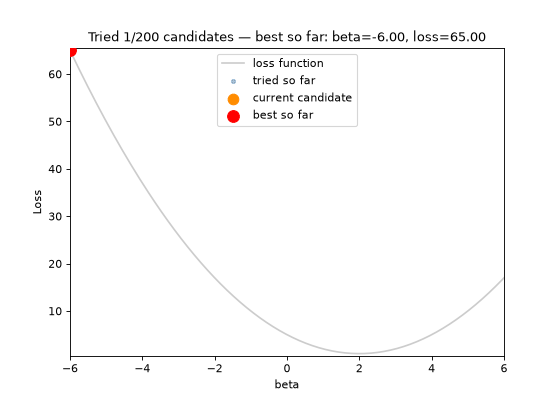

In [2]:
#| code-fold: true
def plot_grid_search_over_time_gif(
    candidates, values, n_frames=50, seconds=5.0, hold_seconds=1.2
):
    """
    Animate a 1D grid search: sweep through candidates one at a time, tracking
    the best (candidate, loss) found so far.
    """
    import base64
    import io

    from IPython.display import HTML, display
    from PIL import Image

    idx = np.linspace(0, len(candidates) - 1, n_frames).astype(int)

    frames = []
    for i in idx:
        seen_values = values[: i + 1]
        best_i = np.argmin(seen_values)
        cur_best_beta = candidates[best_i]
        cur_best_loss = seen_values[best_i]

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(candidates, values, color="0.8", label="loss function")
        ax.scatter(
            candidates[: i + 1],
            seen_values,
            color="steelblue",
            s=12,
            alpha=0.5,
            label="tried so far",
        )
        ax.scatter(
            candidates[i],
            values[i],
            color="darkorange",
            s=90,
            zorder=5,
            label="current candidate",
        )
        ax.scatter(
            cur_best_beta,
            cur_best_loss,
            color="red",
            s=110,
            zorder=6,
            label="best so far",
        )
        ax.set_xlim(candidates[0], candidates[-1])
        ax.set_ylim(values.min() - 0.5, values.max() + 0.5)
        ax.set_xlabel("beta")
        ax.set_ylabel("Loss")
        ax.set_title(
            f"Tried {i + 1}/{len(candidates)} candidates — "
            f"best so far: beta={cur_best_beta:.2f}, loss={cur_best_loss:.2f}"
        )
        ax.legend(loc="upper center")

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=80)
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).convert("RGB"))

    frame_duration = int(1000 * seconds / n_frames)
    hold_duration = int(1000 * hold_seconds)
    durations = [frame_duration] * n_frames
    durations[0] = hold_duration
    durations[-1] = hold_duration

    gif_buf = io.BytesIO()
    frames[0].save(
        gif_buf,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=durations,
        loop=0,
    )
    gif_buf.seek(0)

    # Quarto's HTML renderer does not pick up embedded image/gif outputs, so we
    # emit an <img> tag with the GIF inlined as a base64 data URI instead.
    gif_b64 = base64.b64encode(gif_buf.getvalue()).decode("ascii")
    display(
        HTML(f'<img src="data:image/gif;base64,{gif_b64}" alt="Grid search over time">')
    )


plot_grid_search_over_time_gif(candidates, values)

### What did we just do?

We tried many possible parameter values.
For each value we asked:
\[
\text{How bad is this choice?}
\]

Then we picked the one with the smallest loss.

This is conceptually what many ML systems do for hyperparameters
(e.g., choosing number of neighbors in kNN, polynomial degree, regularization strength).

But there is a problem…


### Why brute-force search is not enough

A real ML model may have:

- 10 parameters (already bad)
- 100 parameters (impossible)
- millions of parameters (neural networks!)

If each parameter needs:

- 100 candidate values
- 100^10 combinations = \(10^{20}\)
- cannot search them all

So we need a smarter way:
instead of trying everything,
we **follow the slope of the loss function**.

This leads to **Gradient Descent**.


### Gradient Descent: The Key Learning Algorithm

Gradient descent is like hiking downhill in fog:

- you cannot see the whole mountain
- but you CAN feel the local slope
- so you step in the steepest downward direction
- repeat until you reach a valley

Mathematically:
$$
\beta \leftarrow \beta - \eta \,\nabla_\beta L(\beta)
$$

where

- \($\nabla_\beta L$\) = gradient (direction of steepest increase)
- \($\eta$\) = learning rate (step size)

Small \($\eta$\) → slow but safe
Large \($\eta$\) → fast but risky (may overshoot or diverge)

We stop when steps become very small or after some iterations.



In [3]:
import matplotlib.pyplot as plt
import numpy as np


def loss(beta):
    return (beta - 2) ** 2 + 1  # minimum at beta = 2


def grad(beta):
    return 2 * (beta - 2)


beta = -4
eta = 0.2
trajectory = [beta]

for _ in range(20):
    beta = beta - eta * grad(beta)
    trajectory.append(beta)

Just like the grid search above, a static plot only shows where gradient descent
*ended up*. The animation below shows the steps themselves: each frame takes one
more step down the loss curve, following the local slope.


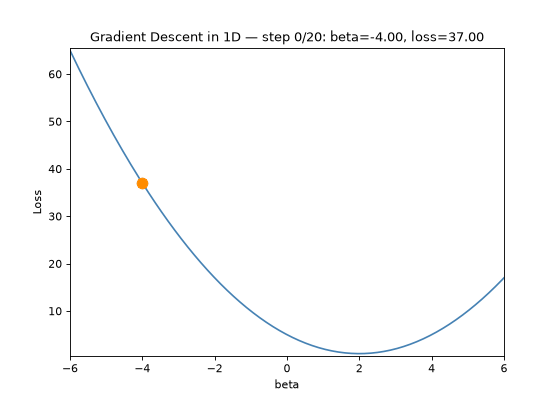

In [4]:
#| code-fold: true
def plot_gradient_descent_1d_gif(loss, trajectory, seconds=5.0, hold_seconds=1.2):
    """
    Animate 1D gradient descent: reveal one more step of the trajectory per
    frame, with a trail connecting the steps taken so far.
    """
    import base64
    import io

    from IPython.display import HTML, display
    from PIL import Image

    b = np.linspace(-6, 6, 200)
    curve = loss(b)
    trajectory = np.array(trajectory)
    losses = loss(trajectory)

    n_frames = len(trajectory)

    frames = []
    for i in range(n_frames):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(b, curve, color="steelblue")
        ax.plot(
            trajectory[: i + 1], losses[: i + 1], color="red", alpha=0.5, linewidth=1
        )
        ax.scatter(trajectory[: i + 1], losses[: i + 1], color="red", s=35, alpha=0.6)
        ax.scatter(trajectory[i], losses[i], color="darkorange", s=90, zorder=5)
        ax.set_xlim(-6, 6)
        ax.set_ylim(curve.min() - 0.5, curve.max() + 0.5)
        ax.set_xlabel("beta")
        ax.set_ylabel("Loss")
        ax.set_title(
            f"Gradient Descent in 1D — step {i}/{n_frames - 1}: "
            f"beta={trajectory[i]:.2f}, loss={losses[i]:.2f}"
        )

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=80)
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).convert("RGB"))

    frame_duration = int(1000 * seconds / n_frames)
    hold_duration = int(1000 * hold_seconds)
    durations = [frame_duration] * n_frames
    durations[0] = hold_duration
    durations[-1] = hold_duration

    gif_buf = io.BytesIO()
    frames[0].save(
        gif_buf,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=durations,
        loop=0,
    )
    gif_buf.seek(0)

    # Quarto's HTML renderer does not pick up embedded image/gif outputs, so we
    # emit an <img> tag with the GIF inlined as a base64 data URI instead.
    gif_b64 = base64.b64encode(gif_buf.getvalue()).decode("ascii")
    display(
        HTML(
            f'<img src="data:image/gif;base64,{gif_b64}" alt="Gradient descent over time">'
        )
    )


plot_gradient_descent_1d_gif(loss, trajectory)

### Interactive Gradient Descent: Learning Rate Matters

The learning rate controls step size.

Use the slider below to see three regimes:

- too small: slow progress,
- just right: steady convergence,
- too large: bouncing or divergence.


In [5]:
def run_gradient_descent_1d(eta=0.2, start=-4.0, steps=20):
    def loss(beta):
        return (beta - 2) ** 2 + 1

    def grad(beta):
        return 2 * (beta - 2)

    beta = start
    trajectory = [beta]
    for _ in range(steps):
        beta = beta - eta * grad(beta)
        trajectory.append(beta)

    b = np.linspace(-6, 6, 400)
    losses = [loss(x) for x in trajectory]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(b, loss(b), color="steelblue")
    axes[0].scatter(trajectory, losses, color="crimson", s=35)
    axes[0].plot(trajectory, losses, color="crimson", alpha=0.5)
    axes[0].set_title(f"Gradient descent path, eta={eta:.2f}")
    axes[0].set_xlabel("parameter beta")
    axes[0].set_ylabel("loss")

    axes[1].plot(losses, marker="o", color="crimson")
    axes[1].set_title("Loss over iterations")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("loss")

    plt.tight_layout()
    plt.show()

    print("final beta:", trajectory[-1])
    print("final loss:", losses[-1])


try:
    import ipywidgets as widgets
    from IPython.display import display

    ui = widgets.interactive(
        run_gradient_descent_1d,
        eta=widgets.FloatSlider(
            value=0.2, min=0.01, max=1.2, step=0.01, description="eta"
        ),
        start=widgets.FloatSlider(
            value=-4.0, min=-6.0, max=6.0, step=0.25, description="start"
        ),
        steps=widgets.IntSlider(value=20, min=1, max=60, step=1, description="steps"),
    )
    display(ui)
except Exception as e:
    print("Widgets are not available here. Running one default example instead.")
    run_gradient_descent_1d(eta=0.2, start=-4.0, steps=20)
    print(e)

interactive(children=(FloatSlider(value=0.2, description='eta', max=1.2, min=0.01, step=0.01), FloatSlider(val…

Try changing the learning rate!

- Too small → slow convergence
- Too large → bouncing / divergence
- Just right → smooth descent

This is the same behavior we will see in neural networks later.



In [6]:
import matplotlib.pyplot as plt
import numpy as np


def loss(beta):
    x, y = beta
    return x**2 + 0.5 * y**2 + 1


def grad(beta):
    x, y = beta
    return np.array([2 * x, y])


eta = 0.2
beta = np.array([3.0, 3.0])
trajectory = [beta.copy()]

for _ in range(25):
    beta -= eta * grad(beta)
    trajectory.append(beta.copy())

trajectory = np.array(trajectory)
trajectory_loss = np.array([loss(pt) for pt in trajectory])

# Plot contours
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + 0.5 * Y**2 + 1


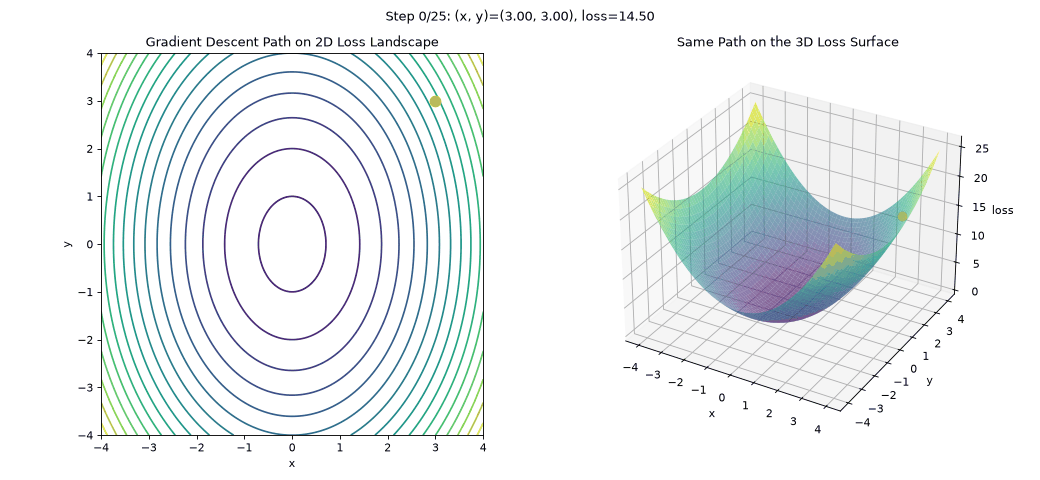

In [7]:
#| code-fold: true
def plot_gradient_descent_2d3d_gif(
    trajectory, trajectory_loss, X, Y, Z, seconds=8.0, hold_seconds=1.2
):
    """
    Animate gradient descent on a 2D loss landscape: reveal one more step of
    the trajectory per frame, on both the contour view and the 3D surface.
    """
    import base64
    import io

    from IPython.display import HTML, display
    from PIL import Image

    n_frames = len(trajectory)

    frames = []
    for i in range(n_frames):
        fig = plt.figure(figsize=(13, 6))

        ax_2d = fig.add_subplot(1, 2, 1)
        ax_2d.contour(X, Y, Z, levels=20)
        ax_2d.plot(
            trajectory[: i + 1, 0], trajectory[: i + 1, 1], marker="o", color="red"
        )
        ax_2d.scatter(
            trajectory[i, 0], trajectory[i, 1], color="darkorange", s=90, zorder=5
        )
        ax_2d.set_title("Gradient Descent Path on 2D Loss Landscape")
        ax_2d.set_xlabel("x")
        ax_2d.set_ylabel("y")
        ax_2d.set_aspect("equal")

        ax_3d = fig.add_subplot(1, 2, 2, projection="3d")
        ax_3d.plot_surface(
            X, Y, Z, cmap="viridis", alpha=0.6, linewidth=0, antialiased=True
        )
        ax_3d.plot(
            trajectory[: i + 1, 0],
            trajectory[: i + 1, 1],
            trajectory_loss[: i + 1],
            marker="o",
            color="red",
            markersize=4,
        )
        ax_3d.scatter(
            trajectory[i, 0],
            trajectory[i, 1],
            trajectory_loss[i],
            color="darkorange",
            s=60,
        )
        ax_3d.set_title("Same Path on the 3D Loss Surface")
        ax_3d.set_xlabel("x")
        ax_3d.set_ylabel("y")
        ax_3d.set_zlabel("loss")

        fig.suptitle(
            f"Step {i}/{n_frames - 1}: (x, y)=({trajectory[i, 0]:.2f}, "
            f"{trajectory[i, 1]:.2f}), loss={trajectory_loss[i]:.2f}"
        )
        plt.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=80)
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).convert("RGB"))

    frame_duration = int(1000 * seconds / n_frames)
    hold_duration = int(1000 * hold_seconds)
    durations = [frame_duration] * n_frames
    durations[0] = hold_duration
    durations[-1] = hold_duration

    gif_buf = io.BytesIO()
    frames[0].save(
        gif_buf,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=durations,
        loop=0,
    )
    gif_buf.seek(0)

    # Quarto's HTML renderer does not pick up embedded image/gif outputs, so we
    # emit an <img> tag with the GIF inlined as a base64 data URI instead.
    gif_b64 = base64.b64encode(gif_buf.getvalue()).decode("ascii")
    display(
        HTML(
            f'<img src="data:image/gif;base64,{gif_b64}" alt="Gradient descent 2D/3D">'
        )
    )


plot_gradient_descent_2d3d_gif(trajectory, trajectory_loss, X, Y, Z)

### Gradient Descent for Linear Regression

Consider a simple regression model:
$$
\hat{y}_i = w x_i + b
$$

Loss:
$$
L(w,b)=\frac{1}{N}\sum_i (y_i-\hat{y}_i)^2
$$

We can compute gradients (you do not need to memorize):
$$
\frac{\partial L}{\partial w} = -\frac{2}{N}\sum_i x_i(y_i-\hat{y}_i)
$$

$$
\frac{\partial L}{\partial b} = -\frac{2}{N}\sum_i (y_i-\hat{y}_i)
$$

Update rules:
$$
w \leftarrow w - \eta \frac{\partial L}{\partial w}
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

This is what libraries like sklearn and PyTorch do for you.


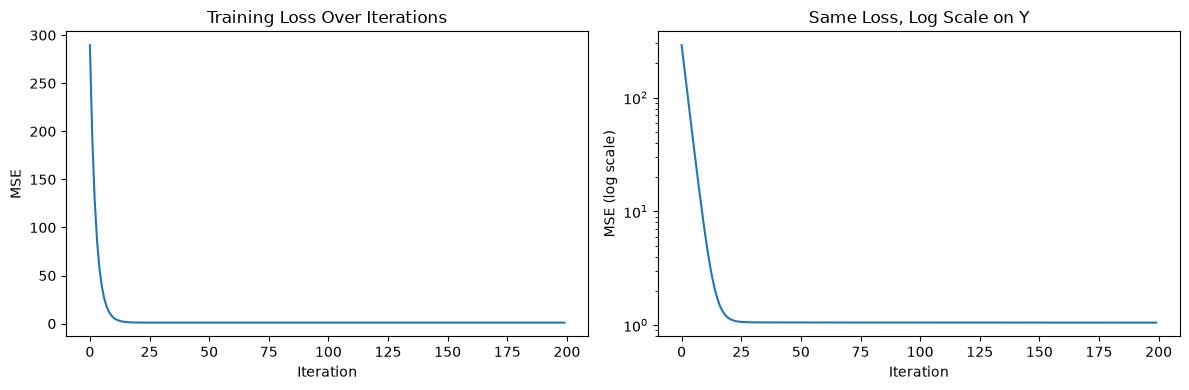

Learned w: 2.3254208662550333
Learned b: 1.7338911227115352


In [8]:
np.random.seed(0)

X = np.linspace(0, 5, 40)
true_w, true_b = 2.5, 1.0
y = true_w * X + true_b + np.random.randn(len(X)) * 1

w, b = -3, 0
eta = 0.01


def predict(X):
    return w * X + b


def mse(y_pred, y):
    return np.mean((y_pred - y) ** 2)


losses = []

for _ in range(200):
    y_pred = predict(X)
    dw = -2 * np.mean(X * (y - y_pred))
    db = -2 * np.mean(y - y_pred)
    w -= eta * dw
    b -= eta * db
    losses.append(mse(y_pred, y))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_title("Training Loss Over Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE")

axes[1].plot(losses)
axes[1].set_yscale("log")
axes[1].set_title("Same Loss, Log Scale on Y")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("MSE (log scale)")

plt.tight_layout()
plt.show()

print("Learned w:", w)
print("Learned b:", b)

### Additional examples
Optimization (finding minima or maxima of a function) is a large field in mathematics, and optimization of complicated functions can be rather involved. Here we will only look at a few very simple cases.

For a more detailed introduction to optimization with SciPy see: https://scipy-lectures.org/advanced/mathematical_optimization/



#### Example 1: Finding a function's minimum

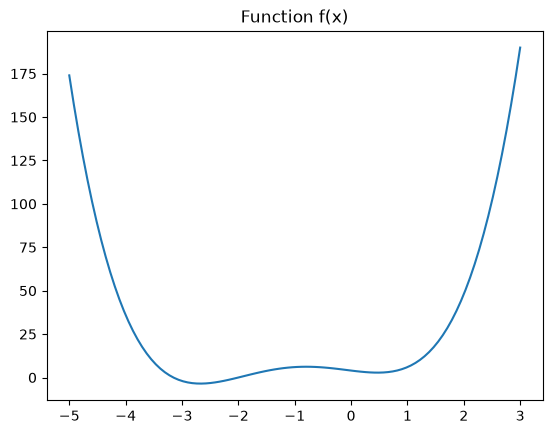

In [9]:
#| code-fold: true
def f(x):
    return 4 * x**3 + (x - 2) ** 2 + x**4


x = np.linspace(-5, 3, 100)
plt.plot(x, f(x))
plt.title("Function f(x)")
plt.show()

The goal is to find the minimum of f(x).

There are many types of optimizers available. If you are interested, you can read more in the [documentation](https://docs.scipy.org/doc/scipy/reference/optimize.html).

In [10]:
from scipy.optimize import minimize

x_min = minimize(f, -4)
print("The minimum is:", x_min.x)

The minimum is: [-2.67298162]


What happens if we start at a different initial point?

#### Example 2: Solving an equation
A related problem is solving an equation, which can be achieved with the `fsolve` function.

Here we want to find `x` such that `g(x)=0`

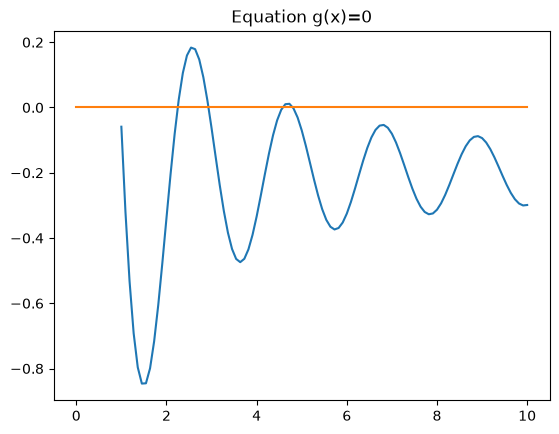

In [11]:
#| code-fold: true
def g(x):
    return np.sin(3 * x) * (1 / x) - 0.2


x = np.linspace(1, 10, 100)
plt.plot(x, g(x))
plt.plot([0, 10], [0, 0])
plt.title("Equation g(x)=0")
plt.show()

In [12]:
from scipy.optimize import fsolve

ans = fsolve(g, 3)
print("The solution is:", ans)

The solution is: [2.93266852]


## Overfitting and Generalization

So far, we’ve focused on *fitting* a model to data.
But the real goal is bigger:

We want a model that performs well on **new, unseen data**.

This property is called **generalization**.

### Overfitting

A model can:

- **Underfit** → too simple, misses structure
- **Just right** → captures true pattern + tolerates noise
- **Overfit** → memorizes training data, learns noise

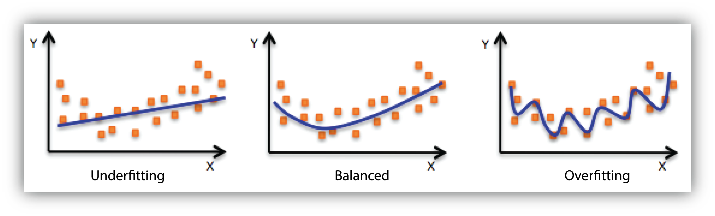

Image credit: https://docs.aws.amazon.com/machine-learning/latest/dg/model-fit-underfitting-vs-overfitting.html


Training error alone is **not enough** to judge a model.
We need to look at how a model behaves on data it did *not* see during training.


### Cross-validation

One way to achieve this goal is through "cross-validation", where some examples ("validation" examples) are hidden when the model is fit to "training" examples, and the loss function is assessed on the hidden validation samples.


There are many strategies for cross-validation:

* *hold-out*: randomly leave out a percentage (usually ~30%) of the data during training.
* *k-fold*: select `k` (usually 3-5) randomly-assigned sub-groups of data, and train `k` times holding each group out.
* *leave p-out*: leave `p` (usually 1) samples out of the training and assess the error for the `p` that were left out. Repeat for all possible `p` subsets of the sample.
* *stratified splitting (or stratified k-fold)*: maintains class proportions across the train/test splits.

Cross-validation is used to determine hyperparameters. In this case, even the "test" sets are used to optimize the model. It is common to select an additional "validation" or "holdout" subset for a final validation of the model.

Important (and often violated) assumption: **The collected data is representative of future data.**

### Visualizing the Roles of Train, Validation, and Test Sets

A useful workflow is:

1. **Training set:** fit model parameters.
2. **Validation set:** choose hyperparameters and model complexity.
3. **Test set:** estimate final performance once, after model selection.

The test set should not guide choices during model development.


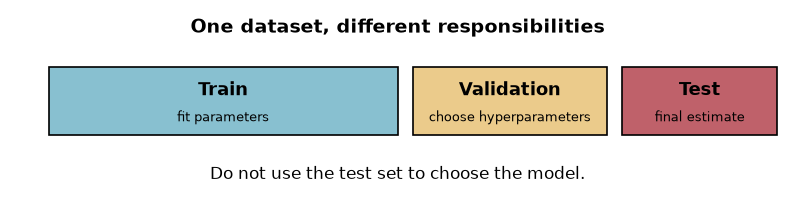

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")

segments = [
    (0.05, 0.35, 0.45, "Train", "fit parameters", "#88c0d0"),
    (0.52, 0.35, 0.25, "Validation", "choose hyperparameters", "#ebcb8b"),
    (0.79, 0.35, 0.20, "Test", "final estimate", "#bf616a"),
]

for x, y, w, label, subtitle, color in segments:
    ax.add_patch(
        Rectangle((x, y), w, 0.35, facecolor=color, edgecolor="black", linewidth=1.2)
    )
    ax.text(
        x + w / 2, y + 0.23, label, ha="center", va="center", fontsize=13, weight="bold"
    )
    ax.text(x + w / 2, y + 0.09, subtitle, ha="center", va="center", fontsize=9)

ax.text(
    0.5,
    0.88,
    "One dataset, different responsibilities",
    ha="center",
    fontsize=14,
    weight="bold",
)
ax.text(
    0.5, 0.12, "Do not use the test set to choose the model.", ha="center", fontsize=12
)
plt.show()

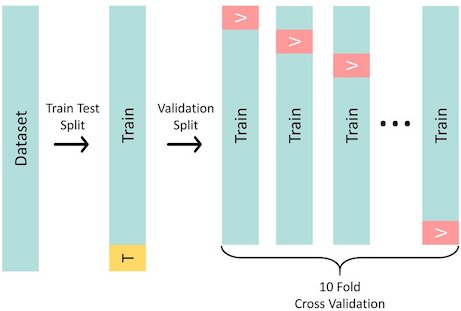

See this [sklearn tutorial](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py) with many examples of splitting strategies for defining training, test, and validation sets!


In [14]:
import numpy as np
from sklearn.model_selection import KFold

X = np.arange(10)

kf = KFold(n_splits=5, shuffle=True, random_state=0)

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}")
    print(" Train indices:", train_idx)
    print(" Test indices:", test_idx)
    print()

Fold 1
 Train indices: [0 1 3 4 5 6 7 9]
 Test indices: [2 8]

Fold 2
 Train indices: [0 1 2 3 5 6 7 8]
 Test indices: [4 9]

Fold 3
 Train indices: [0 2 3 4 5 7 8 9]
 Test indices: [1 6]

Fold 4
 Train indices: [0 1 2 4 5 6 8 9]
 Test indices: [3 7]

Fold 5
 Train indices: [1 2 3 4 6 7 8 9]
 Test indices: [0 5]



## Example

### Generate Noisy Dataset

Let's consider the following function
$$f(x) = \cos(\frac{3}{2} \pi x) + \varepsilon, \forall x \in [0,1]$$
where $\varepsilon \sim \mathcal{N}(0,\sigma^2)$ is drawn from a Gaussian distribution with mean $0$ and variance $\sigma^2$.

Given $n$ samples $(x_i, y_i)$ with $y_i=f(x_i)$, the goal is to find an approximation $\hat f$ of $f$.

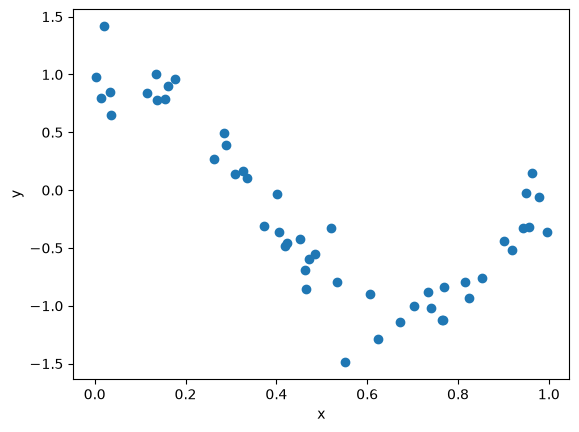

In [15]:
def f(x):
    return np.cos(1.5 * np.pi * x)


def generate_data(n_samples, seed=12):
    np.random.seed(seed=seed)
    # sample points
    X = np.random.rand(n_samples)

    # apply function
    y = f(X)

    # add noise
    y = y + np.random.randn(n_samples) * 0.2  # multiply by standard deviation (sigma)
    return X, y


X, y = generate_data(50)

plt.scatter(X, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Note that there is only one feature so X will be one dimensional.

### Define your train/test split

First step is splitting the data into a train set and test set. The test set will be use to evaluate the generalization performance of the model and should at no point be seen by the model during learning.

`sklearn` provides a utility, [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn-model-selection-train-test-split), that splits arrays into random train and test subsets. We will hold out 30% of the data for testing.

Total number of samples: 50
Number of training samples: 35
Number of testing samples: 15


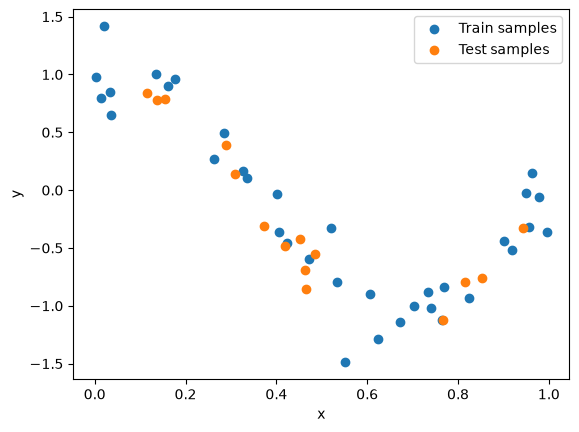

In [16]:
#| code-fold: true
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

print("Total number of samples:", len(X))
print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)
plt.xlabel("x")
plt.ylabel("y")
plt.legend(["Train samples", "Test samples"])
plt.show()

### Fit a model on the training data

We consider a simple model, we can perform linear regression to approximate function `f`. The model will look like this:

$$\hat f(x) = w_0 + w_1 x$$

In [17]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(
    X_train.reshape(-1, 1), y_train
)  # X_train is reshape because reg expects a matrix of size (num_samples, num_feats)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-1.67]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.6949
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.89]


Let's visualize the fitted model

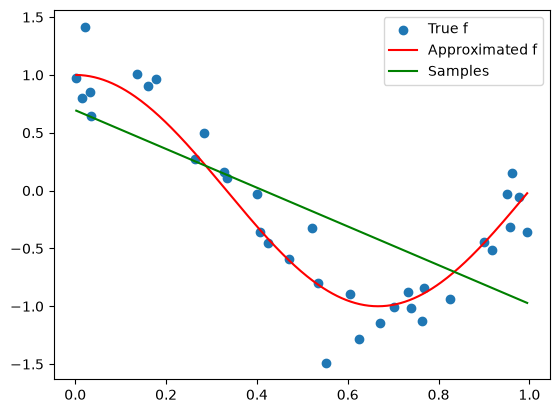

In [18]:
# plot data
plt.scatter(X_train, y_train)

# plot true function
x_grid = np.linspace(X.min(), X.max(), 300)
plt.plot(x_grid, f(x_grid), c="red")

# plot approximate function
plt.plot(x_grid, reg.predict(x_grid.reshape(-1, 1)), c="green")

plt.legend(["True f", "Approximated f", "Samples"])
plt.show()

We can clearly see how the model (in green) is **underfitting** the true function (in red). This will be further reflected when we evaluate the train and test errors.

Compute the error (loss) on our training and test set.

In [19]:
def compute_mean_squared_error(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


print(
    "Train error:",
    compute_mean_squared_error(reg.predict(X_train.reshape(-1, 1)), y_train),
)
print(
    "Test error:",
    compute_mean_squared_error(reg.predict(X_test.reshape(-1, 1)), y_test),
)

Train error: 0.3020592131403804
Test error: 0.17571791533744358


The model performs poorly on both sets.

### Increase the complexity of the features in the model

The next step in this case is to use a more complex model, with potentially more parameters. We can perform **polynomial regression**!

A third-order polynomial, for example, will have the following formula:

$$\hat f(x) = w_0 + w_1 x + w_2 x^2 + w_3 x^3$$

`sklearn` does not provide a PolynomialRegression class unfortunately, but, by computing polynomial features, we can use `LinearRegression`. This is done as follows: X contains one feature of value $x_i$ for each of its $n$ samples. We add polynomial features (up to the desired degree, here 3) as new features of X:

$$
X = \begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n \\
\end{bmatrix}
\Longrightarrow
\begin{bmatrix}
x_1 & x_1^2 & x_1^3 \\
x_2 & x_2^2 & x_2^3\\
\vdots \\
x_n & x_n^2 & x_n^3\\
\end{bmatrix}
$$

In [20]:
def add_polynomial_features(x, deg):
    feats = []
    for i in range(1, deg + 1):
        feats.append(x**i)
    return np.vstack(feats).T


X_train_poly = add_polynomial_features(X_train, deg=3)
X_test_poly = add_polynomial_features(X_test, deg=3)

print(
    "The data is now of shape",
    X_train_poly.shape,
    "and has",
    X_train_poly.shape[1],
    "features.",
)

The data is now of shape (35, 3) and has 3 features.


We can now perform polynomial regression using `LinearRegression`.

In [21]:
polyreg = LinearRegression()
polyreg.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.44,-13.42, 12.17]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.9987
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[3.28,0.58,0.07]"


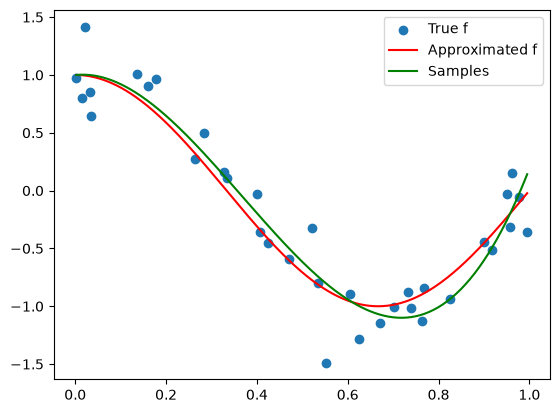

In [22]:
# plot data
plt.scatter(X_train, y_train)

# plot true function
x_grid = np.linspace(X.min(), X.max(), 300)
plt.plot(x_grid, f(x_grid), c="red")

# plot approximate function
x_grid_poly = add_polynomial_features(x_grid, deg=3)
plt.plot(x_grid, polyreg.predict(x_grid_poly), c="green")

plt.legend(["True f", "Approximated f", "Samples"])
plt.show()

The model already looks better, let's look at the errors.

In [23]:
print(
    "Train error:", compute_mean_squared_error(polyreg.predict(X_train_poly), y_train)
)
print("Test error:", compute_mean_squared_error(polyreg.predict(X_test_poly), y_test))

Train error: 0.052729801079907386
Test error: 0.02299273649805278


The performance indeed improved a lot!
But can we do better? Let's give our model more parameters, let's use a polynomial of degree 8.

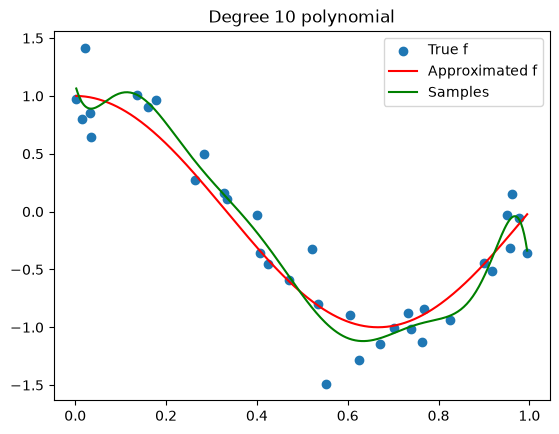

Train error: 0.03653617040618303
Test error: 0.030450487717298698


In [24]:
def fit_polynomial(X_train, y_train, X_test, y_test, deg, plot=False):
    X_train_poly = add_polynomial_features(X_train, deg=deg)
    X_test_poly = add_polynomial_features(X_test, deg=deg)

    polyreg = LinearRegression()
    polyreg.fit(X_train_poly, y_train)

    train_error = compute_mean_squared_error(polyreg.predict(X_train_poly), y_train)
    test_error = compute_mean_squared_error(polyreg.predict(X_test_poly), y_test)

    if plot:
        # plot data
        plt.scatter(X_train, y_train)

        # plot true function
        x_grid = np.linspace(X.min(), X.max(), 300)
        plt.plot(x_grid, f(x_grid), c="red")

        # plot approximate function
        x_grid_poly = add_polynomial_features(x_grid, deg=deg)
        plt.plot(x_grid, polyreg.predict(x_grid_poly), c="green")

        plt.legend(["True f", "Approximated f", "Samples"])
        plt.title("Degree %d polynomial" % deg)
        plt.show()
    return train_error, test_error


train_error, test_error = fit_polynomial(
    X_train, y_train, X_test, y_test, deg=10, plot=True
)
print("Train error:", train_error)
print("Test error:", test_error)

The model now looks more complex, the red curve passes through most training samples, but no longer matches the true function well. While the train error decreases, the test error starts increasing significatly: the model is **overfitting**.

### Model Complexity Demo

Polynomial degree is a hyperparameter that controls model complexity. The
animation below increases the degree one step at a time and refits the model at
each step, so you can watch the fitted curve change continuously.

Look for:

- underfitting: curve too simple, high train and test error,
- good fit: captures the main pattern,
- overfitting: curve bends to chase noisy training points.



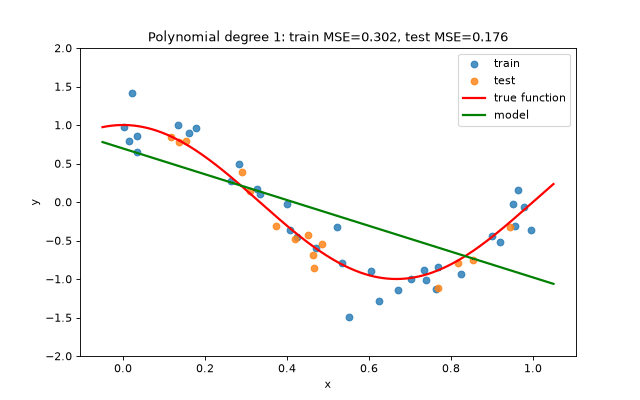

In [25]:
#| code-fold: true
def plot_polynomial_degree_gif(degrees=None, seconds=15.0, hold_seconds=1.2):
    """
    Animate model complexity: refit a polynomial at each degree in `degrees`
    and show train/test MSE alongside the fitted curve.
    """
    import base64
    import io

    from IPython.display import HTML, display
    from PIL import Image

    if degrees is None:
        # A polynomial of degree >= len(X_train) - 1 can perfectly interpolate
        # the training set, so that's a natural, data-driven cap.
        degrees = range(1, len(X_train) + 1)
    degrees = list(degrees)
    x_grid = np.linspace(-0.05, 1.05, 400)

    frames = []
    for deg in degrees:
        X_train_poly = add_polynomial_features(X_train, deg=deg)
        X_test_poly = add_polynomial_features(X_test, deg=deg)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        train_pred = model.predict(X_train_poly)
        test_pred = model.predict(X_test_poly)
        train_error = compute_mean_squared_error(train_pred, y_train)
        test_error = compute_mean_squared_error(test_pred, y_test)

        x_grid_poly = add_polynomial_features(x_grid, deg=deg)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(X_train, y_train, label="train", alpha=0.8)
        ax.scatter(X_test, y_test, label="test", alpha=0.8)
        ax.plot(x_grid, f(x_grid), color="red", linewidth=2, label="true function")
        ax.plot(
            x_grid,
            model.predict(x_grid_poly),
            color="green",
            linewidth=2,
            label="model",
        )
        ax.set_ylim(-2, 2)
        ax.set_title(
            f"Polynomial degree {deg}: train MSE={train_error:.3f}, "
            f"test MSE={test_error:.3f}"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend(loc="upper right")

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=80)
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).convert("RGB"))

    n_frames = len(frames)
    frame_duration = int(1000 * seconds / n_frames)
    hold_duration = int(1000 * hold_seconds)
    durations = [frame_duration] * n_frames
    durations[0] = hold_duration
    durations[-1] = hold_duration

    gif_buf = io.BytesIO()
    frames[0].save(
        gif_buf,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=durations,
        loop=0,
    )
    gif_buf.seek(0)

    # Quarto's HTML renderer does not pick up embedded image/gif outputs, so we
    # emit an <img> tag with the GIF inlined as a base64 data URI instead.
    gif_b64 = base64.b64encode(gif_buf.getvalue()).decode("ascii")
    display(HTML(f'<img src="data:image/gif;base64,{gif_b64}" alt="Model complexity">'))


plot_polynomial_degree_gif()

## Model selection: Validation set

Now that we have seen three different models, how do we proceed to find the appropriate number of parameters or complexity of our model?

One commonly used approach for model selection is defining a set for validation to tune hyperparameters over. We can simulate a "test" set by holding out a few samples from the train set, to create what is called a **validation** set. It is used for hyperparameter tuning (in this case, we need to tune the degree of the polynomial) and acts as a surrogate for the test set.


Let's transform 20% of the training samples to validation samples. The rest of the 80% of the training set will be used to train the model.

In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=3
)

print("Number of remaining training samples:", len(X_train))
print("Number of validation samples:", len(X_val))

Number of remaining training samples: 28
Number of validation samples: 7


We compute errors for different degrees, this allows us to draw the **training curve** and the **validation curve**.

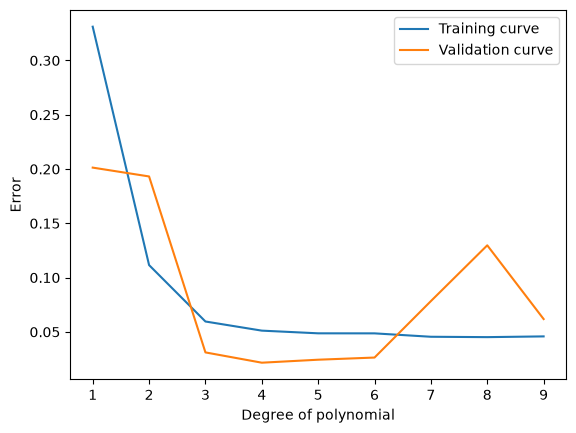

In [27]:
#| code-fold: true
train_errors, val_errors = [], []
deg_range = range(1, 10)
for deg in deg_range:
    train_error, val_error = fit_polynomial(X_train, y_train, X_val, y_val, deg=deg)
    train_errors.append(train_error)
    val_errors.append(val_error)

plt.plot(deg_range, train_errors)
plt.plot(deg_range, val_errors)
plt.legend(["Training curve", "Validation curve"])
plt.xlabel("Degree of polynomial")
plt.ylabel("Error")
plt.show()

### Interactive Validation Curve

A validation curve plots error as a function of model complexity.

The best model is usually not the one with the lowest training error. It is the one with low validation error.


In [28]:
def validation_curve(max_degree=15):
    degrees = range(1, max_degree + 1)
    train_errors, val_errors = [], []

    for deg in degrees:
        train_error, val_error = fit_polynomial(X_train, y_train, X_val, y_val, deg=deg)
        train_errors.append(train_error)
        val_errors.append(val_error)

    best_idx = int(np.argmin(val_errors))
    best_degree = list(degrees)[best_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(degrees, train_errors, marker="o", label="training error")
    plt.plot(degrees, val_errors, marker="o", label="validation error")
    plt.axvline(
        best_degree, color="gray", linestyle="--", label=f"best degree = {best_degree}"
    )
    plt.xlabel("Polynomial degree")
    plt.ylabel("MSE")
    plt.title("Training vs Validation Error")
    plt.legend()
    plt.show()

    print("Best validation degree:", best_degree)
    print("Validation error:", val_errors[best_idx])


try:
    import ipywidgets as widgets
    from IPython.display import display

    ui = widgets.interactive(
        validation_curve,
        max_degree=widgets.IntSlider(
            value=15, min=3, max=25, step=1, description="max degree"
        ),
    )
    display(ui)
except Exception as e:
    print("Widgets are not available here. Running default validation curve instead.")
    validation_curve(max_degree=15)
    print(e)

interactive(children=(IntSlider(value=15, description='max degree', max=25, min=3), Output()), _dom_classes=('…

We see that after increasing the degree of the polynomial beyond 5, the model starts overfitting the data. Thus, a 5-degree polynomial would be appropriate.



Now we can specify our final model.

Train error: 0.04868146958457155
Test error: 0.01851825297775618


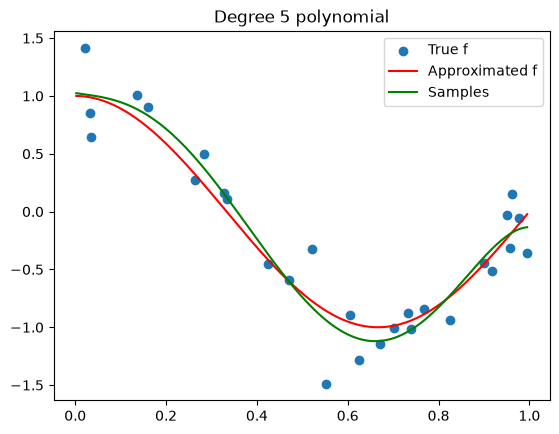

In [29]:
deg = 5

X_train_poly = add_polynomial_features(X_train, deg=deg)
X_test_poly = add_polynomial_features(X_test, deg=deg)

polyreg = LinearRegression()
polyreg.fit(X_train_poly, y_train)

print(
    "Train error:", compute_mean_squared_error(polyreg.predict(X_train_poly), y_train)
)
print("Test error:", compute_mean_squared_error(polyreg.predict(X_test_poly), y_test))

# plot data
plt.scatter(X_train, y_train)

# plot true function
x_grid = np.linspace(X.min(), X.max(), 300)
plt.plot(x_grid, f(x_grid), c="red")

# plot approximate function
x_grid_poly = add_polynomial_features(x_grid, deg=deg)
plt.plot(x_grid, polyreg.predict(x_grid_poly), c="green")

plt.legend(["True f", "Approximated f", "Samples"])
plt.title("Degree %d polynomial" % deg)
plt.show()

## Interpolation vs. Extrapolation

In general, machine learning models can **only** interpolate. There are possible exceptions, but this requires some specialized model development and/or prior knowledge of the nature of the model.

If, for example, we extend the domain definition of our previous function $f$ to from $x\in[0, 1]$ to  $x\in[-1, 2]$, we will see how the model fails to extrapolate outside of the range it was trained on.

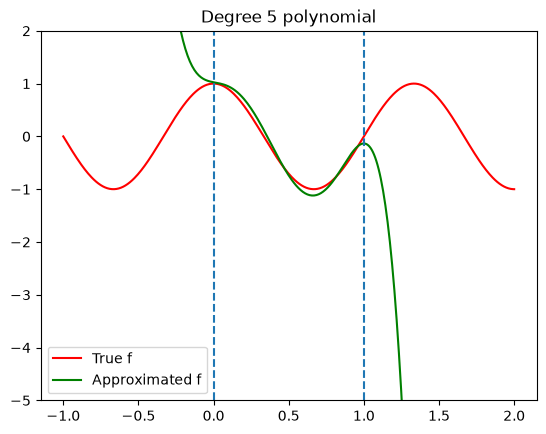

In [30]:
# plot true function
x_grid = np.linspace(-1, 2, 400)
plt.plot(x_grid, f(x_grid), c="red")

# plot approximate function
x_grid_poly = add_polynomial_features(x_grid, deg=deg)
plt.plot(x_grid, polyreg.predict(x_grid_poly), c="green")

plt.legend(["True f", "Approximated f"])
plt.title("Degree %d polynomial" % deg)
plt.ylim([-5, 2])
plt.vlines([0, 1], -5, 2, linestyles="dashed")
plt.show()


"Extrapolation" with machine learning models is typically achieved through search/exploration algorithms or "adaptive learning". These algorithms utilize machine-learning models to produce an iterative experimental design scheme that involves collection of new data. This effectively turns extrapolation problems into interpolation problems.

#### Summary



**Additional resources:**

- Distill article on momentum: https://distill.pub/2017/momentum/
- Overview on cross-validation here: https://scikit-learn.org/stable/modules/cross_validation.html

**Tutorials and related concepts in sklearn:**

- Visualizing cross-validation behavior: https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py
- Comparing various optimizers: https://scikit-learn.org/stable/auto_examples/linear_model/plot_sgd_comparison.html#sphx-glr-auto-examples-linear-model-plot-sgd-comparison-py

### Model Selection Checklist

Before trusting a model, ask:

1. What data did the model train on?
2. What data were used to choose hyperparameters?
3. What data were held out for final testing?
4. Does the model perform similarly on training and validation/test data?
5. Are errors concentrated in a particular part of the input space?
6. Are we interpolating within the training range or extrapolating beyond it?
7. Could a simpler model perform almost as well?

The goal is not to find the most complicated model. The goal is to find a model that generalizes.


### Additional Questions

**Challenge 1.**

1. Randomly assigning samples into a training and test split is the most common approach for cross-validation. Describe at least three of the other evaluation approaches and why they may be useful for different biomedical applications.

>

2. In which scenarios is random sampling no longer sufficient?

>

**Challenge 2.**

1. Why is a model that perfectly fits training data *not always good*?

2. Where do you see “overfitting” in real life?
Examples:

- memorizing exam answers vs understanding
- overtraining in sports
- overly tuned rules or policies

3. Why can’t we judge a model using only training error?


```

Contributors: Mehdi Azabou, Eva Dyer, AJ Medford. Some examples adapted from materials from COE 3803 taught by EL Dyer and AJ Medford.